In [3]:
# Simulated Anealing
# A hill climbing algorithm is grat at finding local optimal solutions, but not global.
# S introduces temperature and ramdomness to improve the hill-climbing algorithm
import numpy as np
import matplotlib .pyplot as plt


In [7]:
# h is the function that we are trying to maximize using simmulated annealing. 
# Below we first define, then vecotrize and plot our h function.
def h(x):
    if x < -1 or x > 1:
        y = 0
    else:
        y = (np.cos(50*x)+np.sin(20*x))
    return y

hv = np.vectorize(h) # Vectorize our h function

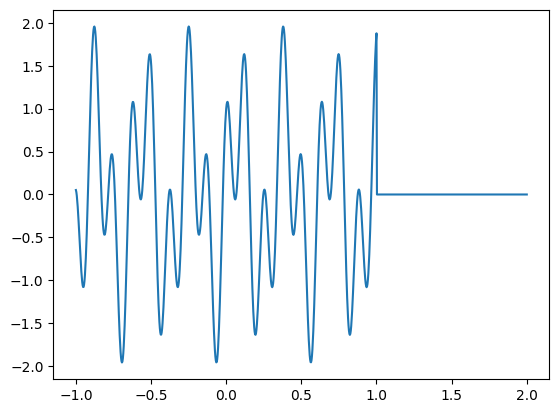

In [5]:
X = np.linspace(-1, 2, num=1000)
plt.plot(X, hv(X))

In [56]:
# This is an implementation of a simple hill-climbing search algorithm called 'greedy' search
def simple_greedy_search(func, start=0, N=100):
    x = start
    history = []
    for i in range(N):
        history.append(x) # keep track of steps
        u = 0.001 #np.random.rand() # introduces noise
        xleft, xright = x-u, x+u
        yleft, yright = func(xleft), func(xright)
        x = xleft if yleft > yright else xright
    return x, history

In [57]:
x0, history = simple_greedy_search(hv, start=-0.02, N=100)

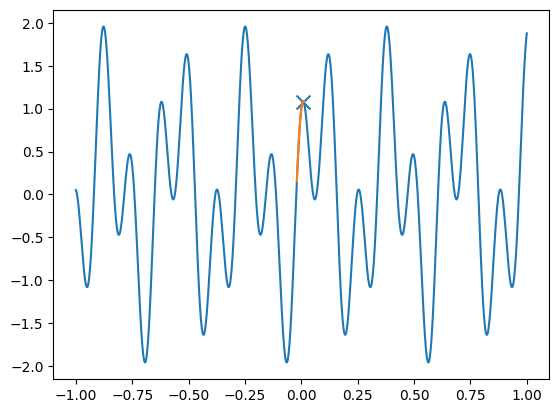

In [58]:
plt.plot(X, hv(X))
plt.scatter(x0, h(x0), marker='x', s=100)
plt.plot(history, hv(history))

In [125]:
def simmulated_annealing(func, T, n_restarts = 5, min_T=1e-4):
    overall_best_x, overall_best_val, overall_best_history = None, -np.inf, []
    for _ in range(n_restarts):
        scale = np.sqrt(T)
        x = np.random.uniform(-1, 1)
        curr = func(x)
        best_val = curr
        best_x = x
        best_history = [x]
        history = [x]
        t = T

        for i in range(1000):
            prop = x + np.random.normal() * scale
            if prop > 1 or prop < -1:
                prop = x
            else:
                delta = func(prop) - curr
                if delta < 0 and np.log(np.random.rand()) > delta / t:
                    prop = x
            x = prop
            curr = func(x)
            t = 0.9 * t
            scale = np.sqrt(t)
            history.append(x)
            if curr > best_val:
                best_val = curr
                best_x = x
                best_history = history[:]
            if t < min_T:
                break
            if best_val > overall_best_val:
                overall_best_val = best_val
                overall_best_x = best_x
                overall_best_history = best_history
    return overall_best_x, overall_best_val, overall_best_history

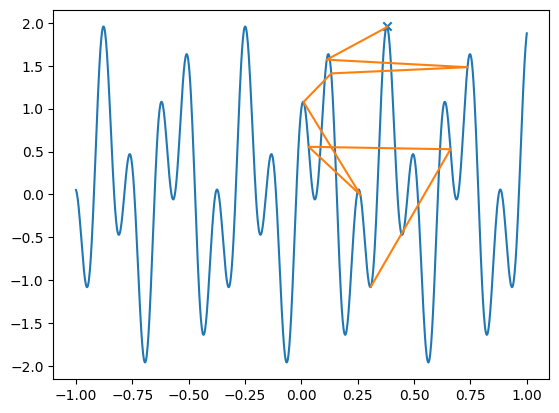

In [128]:
X = np.linspace(-1, 1, num=1000)
best_x, best_val, history = simmulated_annealing(h, T=4)
plt.plot(X, hv(X))
plt.scatter([best_x], [hv(best_x)], marker='x')
plt.plot(history, hv(history))